# Proyek Analisis Data: Olist E-Commerce Dataset
- **Nama:** [Isi Nama]
- **Email:** [Isi Email]
- **ID Dicoding:** [Isi Username Dicoding]

> Analisis ini menggunakan data pesanan, item pesanan, dan ulasan pelanggan untuk periode transaksi yang tersedia pada dataset. Untuk perbandingan tahunan digunakan periode yang sama, **Januari–Agustus**, agar perbandingan 2017 dan 2018 adil.

## Menentukan Pertanyaan Bisnis

### Pertanyaan 1
**Berapa pertumbuhan nilai penjualan produk dan jumlah pesanan berstatus delivered per bulan pada Januari–Agustus 2018 dibandingkan periode yang sama tahun 2017, serta bulan mana yang mengalami pertumbuhan year-over-year tertinggi?**

Kesesuaian SMART:
- **Specific:** fokus pada nilai penjualan dan jumlah pesanan delivered.
- **Measurable:** diukur dengan total `price`, jumlah order unik, dan pertumbuhan YoY (%).
- **Action-Oriented:** dapat digunakan untuk menentukan bulan yang perlu diprioritaskan dalam perencanaan kampanye dan kapasitas operasional.
- **Relevant:** berkaitan langsung dengan perkembangan transaksi e-commerce.
- **Time-bound:** Januari–Agustus 2017 dibanding Januari–Agustus 2018.

### Pertanyaan 2
**Seberapa besar perbedaan rata-rata review score dan proporsi rating rendah (1–2) antara pesanan yang tiba tepat waktu/lebih cepat dan pesanan yang terlambat selama Januari–Agustus 2018?**

Kesesuaian SMART:
- **Specific:** membandingkan kepuasan pelanggan berdasarkan ketepatan waktu pengiriman.
- **Measurable:** menggunakan rata-rata `review_score` dan persentase rating 1–2.
- **Action-Oriented:** hasilnya dapat menjadi dasar prioritas perbaikan SLA/logistik.
- **Relevant:** keterlambatan pengiriman berhubungan dengan pengalaman pelanggan.
- **Time-bound:** Januari–Agustus 2018.

## Import Semua Packages/Library yang Digunakan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

## Data Wrangling

### Gathering Data

Data yang dibutuhkan:
1. `orders_dataset.csv`: status dan waktu pesanan/pengiriman.
2. `order_items_dataset.csv`: nilai `price` setiap item untuk menghitung nilai penjualan.
3. `order_reviews_dataset.csv`: skor ulasan pelanggan.

In [2]:
orders_df = pd.read_csv("data/orders_dataset.csv")
order_items_df = pd.read_csv("data/order_items_dataset.csv")
reviews_df = pd.read_csv("data/order_reviews_dataset.csv")

print("orders:", orders_df.shape)
print("order_items:", order_items_df.shape)
print("reviews:", reviews_df.shape)

display(orders_df.head())
display(order_items_df.head())
display(reviews_df.head())

orders: (99441, 8)
order_items: (112650, 7)
reviews: (99224, 7)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


**Insight:**
- Tabel `orders` berisi satu baris utama untuk setiap pesanan.
- Tabel `order_items` dapat memiliki beberapa baris untuk satu `order_id`, sehingga nilai item perlu diagregasi terlebih dahulu agar tidak menggandakan pesanan.
- Tabel `reviews` digunakan untuk menghubungkan pengalaman pengiriman dengan skor kepuasan pelanggan.

### Assessing Data

In [3]:
# Ringkasan tipe data dan missing value
print("=== ORDERS ===")
orders_df.info()
print("\nMissing value orders:")
display(orders_df.isna().sum().to_frame("missing"))

print("\n=== ORDER ITEMS ===")
order_items_df.info()
print("\nMissing value order_items:")
display(order_items_df.isna().sum().to_frame("missing"))

print("\n=== REVIEWS ===")
reviews_df.info()
print("\nMissing value reviews:")
display(reviews_df.isna().sum().to_frame("missing"))

# Duplicate exact rows
print("\nExact duplicated rows")
print("orders:", orders_df.duplicated().sum())
print("order_items:", order_items_df.duplicated().sum())
print("reviews:", reviews_df.duplicated().sum())

# Duplicate business key pada review
print("\nDuplicate order_id pada reviews:", reviews_df["order_id"].duplicated().sum())

# Validasi nilai numerik
print("Price negatif:", (order_items_df["price"] < 0).sum())
print("Freight negatif:", (order_items_df["freight_value"] < 0).sum())
print("Review score di luar 1-5:", (~reviews_df["review_score"].between(1, 5)).sum())

# Cek missing tanggal delivery khusus order delivered
delivered_raw = orders_df[orders_df["order_status"] == "delivered"]
print("Order delivered dengan tanggal terima kosong:",
      delivered_raw["order_delivered_customer_date"].isna().sum())

=== ORDERS ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB

Missing value orders:


,missing
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,160
order_delivered_carrier_date,1783
order_delivered_customer_date,2965
order_estimated_delivery_date,0



=== ORDER ITEMS ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB

Missing value order_items:


,missing
order_id,0
order_item_id,0
product_id,0
seller_id,0
shipping_limit_date,0
price,0
freight_value,0



=== REVIEWS ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB

Missing value reviews:


,missing
review_id,0
order_id,0
review_score,0
review_comment_title,87656
review_comment_message,58247
review_creation_date,0
review_answer_timestamp,0



Exact duplicated rows
orders: 0


order_items: 0


reviews: 0

Duplicate order_id pada reviews: 551
Price negatif: 0
Freight negatif: 0
Review score di luar 1-5: 0
Order delivered dengan tanggal terima kosong: 8


**Permasalahan yang ditemukan:**
1. **Missing value:** terdapat **8** pesanan berstatus `delivered` tetapi `order_delivered_customer_date` kosong. Baris tersebut tidak dapat digunakan untuk menentukan apakah pengiriman tepat waktu atau terlambat.
2. **Duplicate business key:** terdapat **551** kemunculan `order_id` tambahan pada tabel review. Artinya sebagian pesanan mempunyai lebih dari satu entri review. Jika langsung di-merge, satu pesanan dapat tergandakan dan membuat analisis bias.
3. Missing pada `review_comment_title` dan `review_comment_message` tidak dibersihkan karena kedua kolom tersebut tidak digunakan dalam analisis.
4. Tidak ditemukan harga/freight negatif dan tidak ada review score di luar rentang 1–5.

**Steps to Take:**
- Mengonversi seluruh kolom tanggal ke tipe `datetime`.
- Mempertahankan hanya pesanan `delivered` untuk analisis transaksi yang terealisasi.
- Mengagregasi item menjadi satu baris per `order_id`.
- Untuk order yang mempunyai lebih dari satu review, memakai **review paling akhir berdasarkan `review_answer_timestamp`** sehingga setiap order memiliki satu skor.
- Menghapus baris dengan tanggal terima kosong hanya pada analisis ketepatan pengiriman.

### Cleaning Data

In [4]:
# 1. Konversi kolom tanggal
order_date_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]
for col in order_date_cols:
    orders_df[col] = pd.to_datetime(orders_df[col], errors="coerce")

reviews_df["review_creation_date"] = pd.to_datetime(
    reviews_df["review_creation_date"], errors="coerce"
)
reviews_df["review_answer_timestamp"] = pd.to_datetime(
    reviews_df["review_answer_timestamp"], errors="coerce"
)

# 2. Agregasi item: satu baris per order
order_value_df = (
    order_items_df.groupby("order_id", as_index=False)
    .agg(
        sales_value=("price", "sum"),
        freight_value=("freight_value", "sum"),
        item_count=("order_item_id", "count")
    )
)
order_value_df["total_order_value"] = (
    order_value_df["sales_value"] + order_value_df["freight_value"]
)

# 3. Ambil review terakhir untuk setiap order
reviews_clean_df = (
    reviews_df.sort_values("review_answer_timestamp")
    .drop_duplicates(subset="order_id", keep="last")
    [["order_id", "review_score"]]
)

# 4. Merge ke level order
all_data_df = (
    orders_df
    .merge(order_value_df, on="order_id", how="left")
    .merge(reviews_clean_df, on="order_id", how="left")
)

# 5. Hanya transaksi yang telah delivered
delivered_df = all_data_df[
    all_data_df["order_status"].eq("delivered")
].copy()

print("Jumlah order delivered:", delivered_df["order_id"].nunique())
print("Duplicate order_id setelah cleaning:", delivered_df["order_id"].duplicated().sum())
print("Tanggal terima kosong pada delivered:",
      delivered_df["order_delivered_customer_date"].isna().sum())

display(delivered_df.head())

Jumlah order delivered: 96478
Duplicate order_id setelah cleaning: 0
Tanggal terima kosong pada delivered: 8


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,sales_value,freight_value,item_count,total_order_value,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,29.99,8.72,1.0,38.71,4.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,118.70,22.76,1.0,141.46,4.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,159.90,19.22,1.0,179.12,5.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,45.00,27.20,1.0,72.20,5.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,19.90,8.72,1.0,28.62,5.0


**Insight:**
- Setelah agregasi dan deduplikasi, data berada pada level **satu baris per order**, sehingga nilai penjualan dan review tidak terhitung ganda.
- Delapan order delivered dengan tanggal terima kosong tetap dapat digunakan untuk analisis penjualan, tetapi akan dikeluarkan khusus ketika menghitung status keterlambatan.

## Exploratory Data Analysis (EDA)

### EDA Pertanyaan 1 — Pertumbuhan transaksi Januari–Agustus 2017 vs 2018

In [5]:
# Periode sebanding: Jan-Aug 2017 dan Jan-Aug 2018
q1_df = delivered_df[
    delivered_df["order_purchase_timestamp"].dt.year.isin([2017, 2018])
    & delivered_df["order_purchase_timestamp"].dt.month.between(1, 8)
].copy()

q1_df["year"] = q1_df["order_purchase_timestamp"].dt.year
q1_df["month_num"] = q1_df["order_purchase_timestamp"].dt.month
q1_df["month"] = q1_df["order_purchase_timestamp"].dt.strftime("%b")

monthly_df = (
    q1_df.groupby(["year", "month_num", "month"], as_index=False)
    .agg(
        sales_value=("sales_value", "sum"),
        orders=("order_id", "nunique")
    )
    .sort_values(["month_num", "year"])
)

# Hitung YoY per bulan
sales_pivot = monthly_df.pivot(
    index="month_num", columns="year", values="sales_value"
)
orders_pivot = monthly_df.pivot(
    index="month_num", columns="year", values="orders"
)

yoy_df = pd.DataFrame({
    "sales_2017": sales_pivot[2017],
    "sales_2018": sales_pivot[2018],
    "sales_growth_pct": (sales_pivot[2018] / sales_pivot[2017] - 1) * 100,
    "orders_2017": orders_pivot[2017],
    "orders_2018": orders_pivot[2018],
    "order_growth_pct": (orders_pivot[2018] / orders_pivot[2017] - 1) * 100
}).reset_index()

display(monthly_df)
display(yoy_df.round(2))

sales_2017 = q1_df.loc[q1_df["year"] == 2017, "sales_value"].sum()
sales_2018 = q1_df.loc[q1_df["year"] == 2018, "sales_value"].sum()
orders_2017 = q1_df.loc[q1_df["year"] == 2017, "order_id"].nunique()
orders_2018 = q1_df.loc[q1_df["year"] == 2018, "order_id"].nunique()

print(f"Total sales Jan-Aug 2017: {sales_2017:,.2f}")
print(f"Total sales Jan-Aug 2018: {sales_2018:,.2f}")
print(f"Pertumbuhan sales: {(sales_2018/sales_2017-1)*100:.2f}%")
print(f"Pertumbuhan jumlah order: {(orders_2018/orders_2017-1)*100:.2f}%")

best_sales_month = yoy_df.loc[yoy_df["sales_growth_pct"].idxmax()]
print(
    f"Pertumbuhan sales YoY tertinggi terjadi pada bulan ke-"
    f"{int(best_sales_month['month_num'])}: "
    f"{best_sales_month['sales_growth_pct']:.2f}%"
)

,year,month_num,month,sales_value,orders
0,2017,1,Jan,111798.36,750
8,2018,1,Jan,924645.00,7069
1,2017,2,Feb,234223.40,1653
9,2018,2,Feb,826437.13,6555
2,2017,3,Mar,359198.85,2546
10,2018,3,Mar,953356.25,7003
3,2017,4,Apr,340669.68,2303
11,2018,4,Apr,973534.09,6798
4,2017,5,May,489338.25,3546
12,2018,5,May,977544.69,6749


,month_num,sales_2017,sales_2018,sales_growth_pct,orders_2017,orders_2018,order_growth_pct
0,1,111798.36,924645.00,727.06,750,7069,842.53
1,2,234223.40,826437.13,252.84,1653,6555,296.55
2,3,359198.85,953356.25,165.41,2546,7003,175.06
3,4,340669.68,973534.09,185.77,2303,6798,195.18
4,5,489338.25,977544.69,99.77,3546,6749,90.33
5,6,421923.37,856077.86,102.90,3135,6099,94.55
6,7,481604.52,867953.46,80.22,3872,6159,59.07
7,8,554699.70,838576.64,51.18,4193,6351,51.47


Total sales Jan-Aug 2017: 2,993,456.13
Total sales Jan-Aug 2018: 7,218,125.12
Pertumbuhan sales: 141.13%
Pertumbuhan jumlah order: 139.94%
Pertumbuhan sales YoY tertinggi terjadi pada bulan ke-1: 727.06%


### EDA Pertanyaan 2 — Ketepatan pengiriman dan review score

In [6]:
q2_df = delivered_df[
    (delivered_df["order_purchase_timestamp"] >= "2018-01-01")
    & (delivered_df["order_purchase_timestamp"] < "2018-09-01")
].copy()

# Hapus hanya baris yang tidak dapat dipakai untuk analisis delivery/review
q2_df = q2_df.dropna(subset=[
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
    "review_score"
])

q2_df["delivery_status"] = np.where(
    q2_df["order_delivered_customer_date"]
    <= q2_df["order_estimated_delivery_date"],
    "On-time / early",
    "Late"
)

q2_df["delay_days"] = (
    q2_df["order_delivered_customer_date"]
    - q2_df["order_estimated_delivery_date"]
).dt.total_seconds() / 86400

q2_df["low_rating"] = q2_df["review_score"].le(2)

delivery_summary_df = (
    q2_df.groupby("delivery_status", as_index=False)
    .agg(
        orders=("order_id", "nunique"),
        avg_review=("review_score", "mean"),
        low_rating_pct=("low_rating", "mean"),
        median_delay_days=("delay_days", "median")
    )
)

delivery_summary_df["low_rating_pct"] *= 100
display(delivery_summary_df.round(2))

late_rate = (q2_df["delivery_status"] == "Late").mean() * 100
print(f"Late delivery rate: {late_rate:.2f}%")

,delivery_status,orders,avg_review,low_rating_pct,median_delay_days
0,Late,4853,2.57,53.76,5.74
1,On-time / early,47609,4.30,9.25,-12.12


Late delivery rate: 9.25%


**Insight EDA:**
- Nilai penjualan Januari–Agustus 2018 jauh lebih tinggi dibanding periode yang sama pada 2017.
- Pertumbuhan sangat tinggi pada awal 2018 karena basis transaksi awal 2017 masih relatif kecil; karena itu persentase YoY perlu dibaca bersama nilai absolutnya.
- Pada Januari–Agustus 2018, sebagian besar order tiba tepat waktu/lebih cepat, tetapi kelompok yang terlambat menunjukkan skor review yang jauh lebih rendah dan proporsi rating 1–2 yang jauh lebih besar.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Pertumbuhan nilai penjualan dan jumlah order

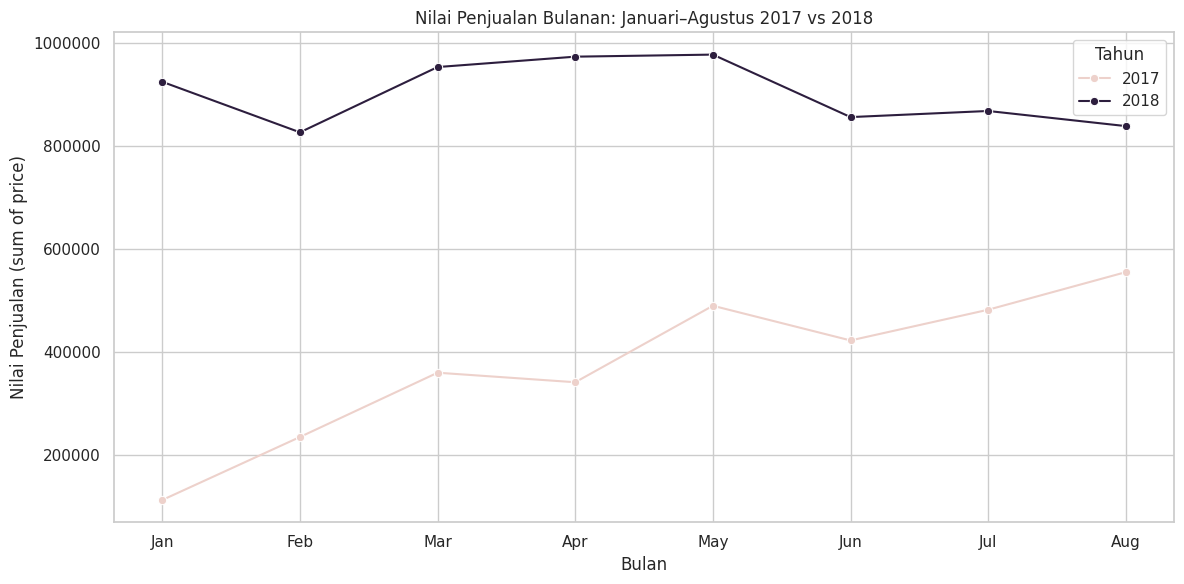

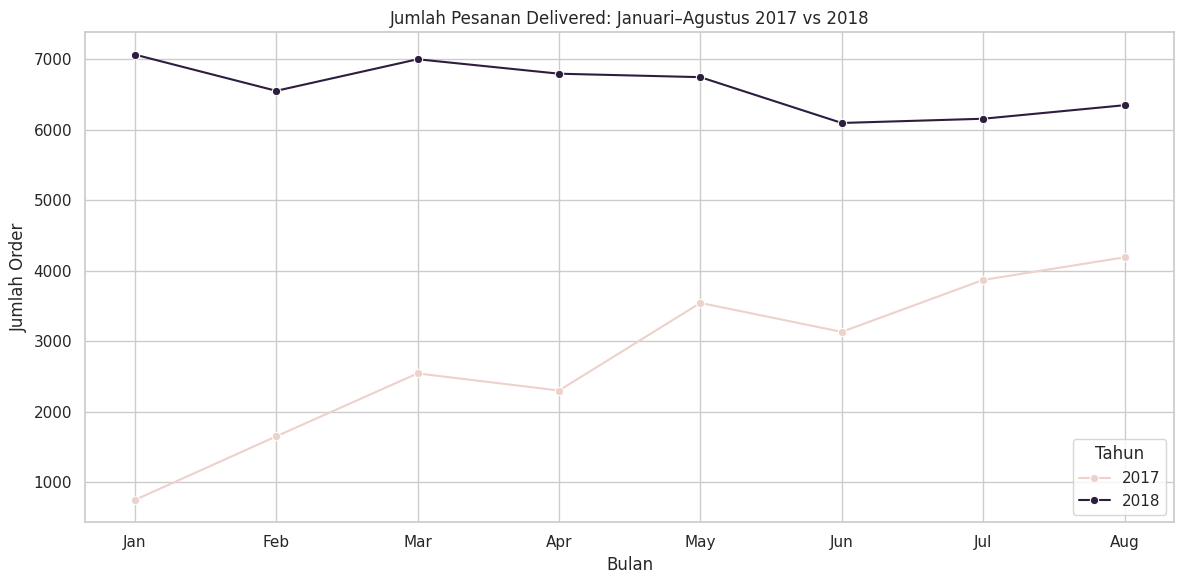

In [7]:
month_order = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug"]
plot_df = monthly_df.copy()
plot_df["month"] = pd.Categorical(
    plot_df["month"], categories=month_order, ordered=True
)

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=plot_df,
    x="month",
    y="sales_value",
    hue="year",
    marker="o"
)
plt.title("Nilai Penjualan Bulanan: Januari–Agustus 2017 vs 2018")
plt.xlabel("Bulan")
plt.ylabel("Nilai Penjualan (sum of price)")
plt.ticklabel_format(style="plain", axis="y")
plt.legend(title="Tahun")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=plot_df,
    x="month",
    y="orders",
    hue="year",
    marker="o"
)
plt.title("Jumlah Pesanan Delivered: Januari–Agustus 2017 vs 2018")
plt.xlabel("Bulan")
plt.ylabel("Jumlah Order")
plt.legend(title="Tahun")
plt.tight_layout()
plt.show()

**Interpretasi Pertanyaan 1:**
- Total nilai penjualan meningkat dari sekitar **2,99 juta** pada Januari–Agustus 2017 menjadi sekitar **7,22 juta** pada Januari–Agustus 2018, atau naik sekitar **141,13%**.
- Jumlah order delivered meningkat dari **21.998** menjadi **52.783**, atau sekitar **139,94%**.
- Pertumbuhan YoY nilai penjualan tertinggi terjadi pada **Januari 2018**, sekitar **727,07%** dibanding Januari 2017. Angka ini perlu dibaca dengan hati-hati karena Januari 2017 memiliki basis transaksi yang rendah.
- Secara absolut, nilai penjualan bulanan 2018 relatif tinggi dan stabil sepanjang Januari–Agustus dibandingkan 2017.

### Pertanyaan 2: Dampak keterlambatan terhadap kepuasan pelanggan

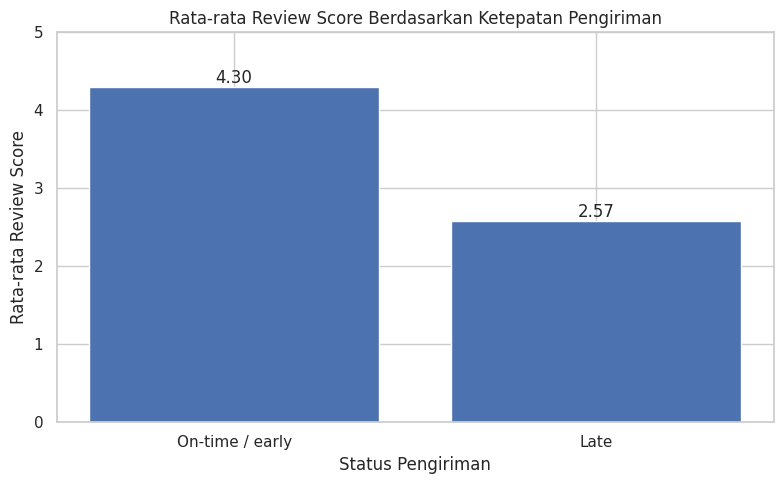

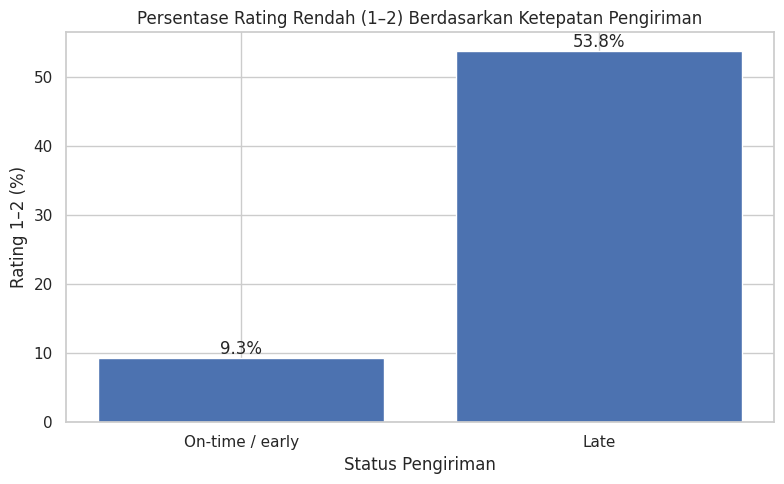

In [8]:
status_order = ["On-time / early", "Late"]
plot_summary = (
    delivery_summary_df.set_index("delivery_status")
    .reindex(status_order)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(plot_summary["delivery_status"], plot_summary["avg_review"])
ax.set_title("Rata-rata Review Score Berdasarkan Ketepatan Pengiriman")
ax.set_xlabel("Status Pengiriman")
ax.set_ylabel("Rata-rata Review Score")
ax.set_ylim(0, 5)
ax.bar_label(bars, fmt="%.2f")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(plot_summary["delivery_status"], plot_summary["low_rating_pct"])
ax.set_title("Persentase Rating Rendah (1–2) Berdasarkan Ketepatan Pengiriman")
ax.set_xlabel("Status Pengiriman")
ax.set_ylabel("Rating 1–2 (%)")
ax.bar_label(bars, fmt="%.1f%%")
plt.tight_layout()
plt.show()

**Interpretasi Pertanyaan 2:**
- Order yang tiba **tepat waktu/lebih cepat** memiliki rata-rata review sekitar **4,30**, sedangkan order **terlambat** hanya sekitar **2,57**.
- Selisih rata-rata review kedua kelompok sekitar **1,73 poin** pada skala 1–5.
- Rating rendah (1–2) hanya sekitar **9,25%** pada pengiriman tepat waktu/lebih cepat, tetapi mencapai sekitar **53,76%** pada pengiriman terlambat.
- Sekitar **9,25%** order yang dapat dievaluasi pada Januari–Agustus 2018 termasuk terlambat. Pola ini menunjukkan keterlambatan merupakan area operasional yang layak diprioritaskan untuk menjaga pengalaman pelanggan.

## Analisis Lanjutan (Opsional)

In [9]:
# Melihat pola review berdasarkan tingkat keterlambatan
delay_analysis_df = q2_df.copy()
delay_analysis_df["delay_group"] = pd.cut(
    delay_analysis_df["delay_days"],
    bins=[-np.inf, 0, 3, 7, np.inf],
    labels=["On-time / early", "Late 1-3 days", "Late 4-7 days", "Late >7 days"]
)

delay_review_df = (
    delay_analysis_df.groupby("delay_group", observed=True, as_index=False)
    .agg(
        orders=("order_id", "nunique"),
        avg_review=("review_score", "mean")
    )
)
display(delay_review_df.round(2))

,delay_group,orders,avg_review
0,On-time / early,47609,4.30
1,Late 1-3 days,1693,3.84
2,Late 4-7 days,1155,2.29
3,Late >7 days,2005,1.67


**Insight tambahan:**
Pengelompokan berdasarkan jumlah hari keterlambatan membantu melihat bahwa masalah tidak hanya terletak pada status terlambat/tidak, tetapi juga pada tingkat keterlambatannya. Informasi ini dapat dipakai untuk menentukan ambang SLA yang lebih ketat.

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** Pada periode Januari–Agustus, nilai penjualan produk naik dari sekitar **2,99 juta pada 2017** menjadi **7,22 juta pada 2018** (**+141,13%**). Jumlah order delivered juga meningkat dari **21.998** menjadi **52.783** (**+139,94%**). Persentase pertumbuhan YoY tertinggi terjadi pada Januari 2018, tetapi besarnya pertumbuhan ini turut dipengaruhi basis transaksi Januari 2017 yang masih rendah.
- **Conclusion pertanyaan 2:** Pada Januari–Agustus 2018, pengiriman tepat waktu/lebih cepat memperoleh rata-rata review sekitar **4,30**, sedangkan pengiriman terlambat sekitar **2,57**. Proporsi rating rendah 1–2 naik tajam dari sekitar **9,25%** menjadi **53,76%** pada order terlambat. Dengan demikian, keterlambatan pengiriman berkaitan dengan pengalaman pelanggan yang lebih buruk pada data ini.

### Rekomendasi Action Item
1. **Perencanaan kapasitas:** gunakan pola volume 2018 sebagai dasar penyiapan kapasitas fulfillment, terutama pada bulan dengan jumlah order tinggi, bukan hanya melihat persentase pertumbuhan YoY.
2. **Prioritas SLA pengiriman:** fokus menurunkan late delivery rate dengan monitoring order yang mendekati estimated delivery date dan evaluasi partner/rute logistik yang sering terlambat.
3. **KPI operasional:** pantau secara rutin `late delivery rate`, `average review score`, dan `% rating 1–2` secara bersamaan. Target perbaikan keterlambatan sebaiknya dikaitkan langsung dengan perubahan metrik kepuasan pelanggan.
4. Analisis ini menunjukkan **asosiasi**, bukan bukti kausal. Faktor lain seperti kondisi produk atau pelayanan penjual juga dapat memengaruhi review score.

## Menyiapkan Data untuk Dashboard Streamlit

In [10]:
dashboard_df = delivered_df[
    (delivered_df["order_purchase_timestamp"] >= "2017-01-01")
    & (delivered_df["order_purchase_timestamp"] < "2018-09-01")
].copy()

dashboard_df["delivery_status"] = pd.Series(pd.NA, index=dashboard_df.index, dtype="object")
valid_delivery = dashboard_df["order_delivered_customer_date"].notna()
dashboard_df.loc[
    valid_delivery
    & (
        dashboard_df["order_delivered_customer_date"]
        <= dashboard_df["order_estimated_delivery_date"]
    ),
    "delivery_status"
] = "On-time / early"
dashboard_df.loc[
    valid_delivery
    & (
        dashboard_df["order_delivered_customer_date"]
        > dashboard_df["order_estimated_delivery_date"]
    ),
    "delivery_status"
] = "Late"

dashboard_df["delay_days"] = (
    dashboard_df["order_delivered_customer_date"]
    - dashboard_df["order_estimated_delivery_date"]
).dt.total_seconds() / 86400

dashboard_columns = [
    "order_id",
    "order_purchase_timestamp",
    "sales_value",
    "freight_value",
    "total_order_value",
    "item_count",
    "review_score",
    "delivery_status",
    "delay_days"
]

dashboard_df[dashboard_columns].to_csv(
    "dashboard/main_data.csv", index=False
)

print("dashboard/main_data.csv berhasil dibuat:", dashboard_df.shape[0], "baris")

dashboard/all_data.csv berhasil dibuat: 96211 baris
